# 08 – Video + Text Fusion Layer & Mismatch Detection
**Project:** MoodSyncAI — Multi-Modal Sentiment & Emotion Analyser

## Pipeline
```
Real .mp4 Video (RAVDESS)
 │
 ▼
PyAV Decoder → uniform 16-frame sample
 │
 ▼
R3D-18 backbone → Temporal Attention Pool → FC(512→256→7)
 │
 ▼
7-Class Video Emotion Probabilities     RoBERTa Text Sentiment
angry|disgust|fear|happy|neutral|sad|surprise    negative|neutral|positive
 │                                                    │
 └──────────────── Polarity Bridge ──────────────────┘
                         │
                         ▼
            Fusion + Mismatch Detection
         MATCH | SOFT_MISMATCH | HARD_MISMATCH
```

### Saved Files from Notebook 7
| File | Role |
|---|---|
| `saved_models/video_emotion/best_video_model.pt` | Trained R3D-18 weights |
| `saved_models/video_emotion/video_label_encoder.pkl` | Index ↔ emotion-string mapping |
| `saved_models/video_emotion/video_model_meta.json` | Hyper-params (frames, size, etc.) |
| `saved_models/roberta_sentiment/` | Fine-tuned RoBERTa-base (3-class) |


## 0 – Imports & Constants

In [4]:
import os, sys, time, warnings, json, pickle, random
warnings.filterwarnings('ignore')
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn as nn
import torchvision.transforms as T
from torchvision.models.video import r3d_18
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Paths ─────────────────────────────────────────────────────────────────────
# The notebook is in `notebooks/`, so we need to go up one level for `saved_models/`
ROOT_DIR = Path('../')
VIDEO_SAVE_DIR   = ROOT_DIR / 'saved_models/video_emotion'
VIDEO_MODEL_PATH = VIDEO_SAVE_DIR / 'best_video_model.pt'
VIDEO_LE_PATH    = VIDEO_SAVE_DIR / 'video_label_encoder.pkl'
VIDEO_META_PATH  = VIDEO_SAVE_DIR / 'video_model_meta.json'
TEXT_MODEL_PATH  = ROOT_DIR / 'saved_models/text_sentiment'

CONF_THRESHOLD = 0.50

# ── Polarity bridge (mirrors notebook 7) ─────────────────────────────────────
VIDEO_TO_POLARITY = {
    'happy'  : 'positive', 'surprise': 'positive',
    'neutral': 'neutral',
    'angry'  : 'negative', 'disgust' : 'negative',
    'fear'   : 'negative', 'sad'     : 'negative',
}

SEVERITY_COLOURS = {
    'MATCH'        : '#4CAF50',
    'SOFT_MISMATCH': '#FFA726',
    'HARD_MISMATCH': '#EF5350',
}
SEVERITY_EMOJI = {
    'MATCH': '✅', 'SOFT_MISMATCH': '⚠️', 'HARD_MISMATCH': '🚨'
}
EMOTION_COLOURS = {
    'angry'  :'#EF5350','disgust':'#AB47BC','fear'   :'#FF7043',
    'happy'  :'#4CAF50','neutral':'#FFA726','sad'    :'#42A5F5','surprise':'#81C784',
}

plt.rcParams.update({
    'figure.facecolor':'#111111','axes.facecolor':'#1c1c1c',
    'axes.edgecolor'  :'#333333','axes.labelcolor':'#cccccc',
    'xtick.color'     :'#aaaaaa','ytick.color'    :'#aaaaaa',
    'text.color'      :'#e0e0e0','grid.color'     :'#2a2a2a',
    'grid.linestyle'  :'--','font.family':'DejaVu Sans',
})

print(f'Python  : {sys.version.split()[0]}')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')

Python  : 3.10.16
PyTorch : 2.2.2+cpu
Device  : cpu


## 1 – Load `video_model_meta.json` & `video_label_encoder.pkl`

**Why load `video_model_meta.json` first?**
It stores the exact hyper-parameters used in notebook 7 (frames, crop size, etc.).
Loading it here guarantees this notebook is always in sync with how the model was trained —
no hard-coded values.

**Why load `video_label_encoder.pkl`?**
It maps integer class indices to emotion strings in the exact order the model was trained on.
Never hard-code the class list — always derive it from the saved encoder.


In [5]:
# ── Load meta ─────────────────────────────────────────────────────────────────
with open(VIDEO_META_PATH) as f:
    meta = json.load(f)

NUM_FRAMES  = meta.get('num_frames',  16)
FRAME_SIZE  = meta.get('frame_size', 112)
NUM_CLASSES = meta.get('num_classes',  7)

print('Hyper-parameters loaded from video_model_meta.json:')
for k, v in meta.items():
    print(f'  {k:<25}: {v}')

# ── Load label encoder ────────────────────────────────────────────────────────
with open(VIDEO_LE_PATH, 'rb') as f:
    le = pickle.load(f)

EMOTION_CLASSES = list(le.classes_)
print(f'\nEmotion classes ({len(EMOTION_CLASSES)}): {EMOTION_CLASSES}')

Hyper-parameters loaded from video_model_meta.json:
  model_name               : VideoEmotionModel_R3D18
  backbone                 : r3d_18 (Kinetics-400 pretrained)
  dataset                  : RAVDESS — real .mp4 video clips
  num_classes              : 7
  emotion_classes          : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
  polarity_map             : {'happy': 'positive', 'surprise': 'positive', 'neutral': 'neutral', 'angry': 'negative', 'disgust': 'negative', 'fear': 'negative', 'sad': 'negative'}
  img_size                 : 112
  num_frames               : 16
  best_val_acc             : 0.8052
  test_acc                 : 0.7226
  conf_threshold           : 0.5
  checkpoint               : saved_models/video_emotion/best_video_model.pt
  label_encoder            : saved_models/video_emotion/label_encoder.pkl

Emotion classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## 2 – Rebuild Video Model & Load `best_video_model.pt`

**Architecture — identical to notebook 7:**
`R3D-18 backbone (Kinetics-400 pretrained) → Temporal Attention Pool → FC(512→256→7)`

The checkpoint was saved whenever validation accuracy improved during training —
it is the best-performing snapshot, not the final epoch weights.


In [42]:
class TemporalAttentionPool(nn.Module):
    """Soft attention over temporal dimension after R3D spatial features.
    Accepts (B, C, T, H, W) and performs spatial mean to (B, C, T).
    """
    def __init__(self, in_dim: int = 512):
        super().__init__()
        self.attn = nn.Linear(in_dim, 1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Expected from backbone: (B, C, T, H, W) with H,W >= 1
        if x.dim() != 5:
            raise RuntimeError(f"TemporalAttentionPool expects 5D tensor (B,C,T,H,W), got {x.dim()}D")
        # Spatial mean → (B, C, T)
        x = x.mean(dim=(3, 4))
        # (B, C, T) → (B, T, C)
        x = x.permute(0, 2, 1)
        # Attention over time
        w = torch.softmax(self.attn(x), dim=1)  # (B, T, 1)
        return (w * x).sum(dim=1)               # (B, C)


class VideoEmotionModel(nn.Module):
    """R3D-18 + Temporal Attention + FC head for 7-class emotion."""
    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()
        backbone_r3d = r3d_18(weights=None)
        self.backbone   = nn.Sequential(*list(backbone_r3d.children())[:-2])
        self.temp_attn  = TemporalAttentionPool(512)
        # Head layout matching checkpoint: LayerNorm(512) → Linear(512→256) → ReLU → Dropout → Linear(256→num_classes)
        self.head       = nn.Sequential(
            nn.LayerNorm(512),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Backbone returns (B, C, T, H, W); pool spatially then attend temporally.
        feats = self.backbone(x)
        pooled = self.temp_attn(feats)
        return self.head(pooled)


def _extract_state_dict(obj):
    # Handle checkpoints saved as {'state_dict': ..., ...} or {'model': ...}
    if isinstance(obj, dict):
        for k in ['state_dict', 'model', 'net', 'weights']:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj if isinstance(obj, dict) else None


def _remap_keys(sd: dict) -> dict:
    remapped = {}
    for k, v in sd.items():
        nk = k
        if nk.startswith('module.'):
            nk = nk[len('module.'):]
        nk = nk.replace('features.', 'backbone.')
        nk = nk.replace('pool.', 'temp_attn.')
        nk = nk.replace('classifier.', 'head.')
        remapped[nk] = v
    return remapped


def _filter_shape_compatible(sd: dict, model: nn.Module) -> dict:
    msd = model.state_dict()
    out = {}
    for k, v in sd.items():
        if k in msd and getattr(v, 'shape', None) == msd[k].shape:
            out[k] = v
    return out


video_model = VideoEmotionModel(num_classes=NUM_CLASSES).to(DEVICE)

ckpt = torch.load(VIDEO_MODEL_PATH, map_location=DEVICE)
raw_sd = _extract_state_dict(ckpt)
if raw_sd is None:
    raise RuntimeError('Checkpoint does not contain a state_dict')

sd_all = _remap_keys(raw_sd)
sd_fit = _filter_shape_compatible(sd_all, video_model)

load_result = video_model.load_state_dict(sd_fit, strict=False)
video_model.eval()

missing = getattr(load_result, 'missing_keys', [])
unexpected = getattr(load_result, 'unexpected_keys', [])
loaded = len(sd_fit) - len(unexpected)

print(f'✓ Video model loaded from : {VIDEO_MODEL_PATH}')
print(f'  Architecture             : R3D-18 + Temporal Attention Pool')
print(f'  Loaded weights           : {loaded} tensors (missing: {len(missing)}, unexpected: {len(unexpected)})')
if missing:
    print('  Missing keys (truncated):', ', '.join(missing[:6]) + (' ...' if len(missing)>6 else ''))
if unexpected:
    print('  Unexpected keys (trunc.):', ', '.join(unexpected[:6]) + (' ...' if len(unexpected)>6 else ''))

total_params = sum(p.numel() for p in video_model.parameters())
print(f'  Parameters               : {total_params:,}')
print(f'  Input                    : (B, 3, {NUM_FRAMES}, {FRAME_SIZE}, {FRAME_SIZE})')
print(f'  Output classes           : {NUM_CLASSES}')

✓ Video model loaded from : ..\saved_models\video_emotion\best_video_model.pt
  Architecture             : R3D-18 + Temporal Attention Pool
  Loaded weights           : 128 tensors (missing: 0, unexpected: 0)
  Parameters               : 33,300,936
  Input                    : (B, 3, 16, 112, 112)
  Output classes           : 7


## 3 – Load Text Model (RoBERTa Sentiment)

In [7]:
print(f'Loading RoBERTa from: {TEXT_MODEL_PATH}')
t0 = time.time()
text_config    = AutoConfig.from_pretrained(TEXT_MODEL_PATH)
text_tokenizer = AutoTokenizer.from_pretrained(TEXT_MODEL_PATH)
text_model     = AutoModelForSequenceClassification.from_pretrained(TEXT_MODEL_PATH).to(DEVICE)
text_model.eval()
print(f'✓ Loaded in {time.time()-t0:.1f}s')
TEXT_LABELS = [text_config.id2label[i] for i in range(len(text_config.id2label))]
print(f'  Labels: {TEXT_LABELS}')

Loading RoBERTa from: ..\saved_models\text_sentiment
✓ Loaded in 11.8s
  Labels: ['negative', 'neutral', 'positive']


## 4 – Frame Preprocessing

The transform pipeline is **identical to the validation transform used in notebook 7** —
resize to 112×112, centre-crop, ImageNet normalisation.
Applying the same normalisation at inference as during training is critical;
any deviation would shift the feature distribution and degrade accuracy.


In [8]:
IMAGENET_MEAN = [0.43216, 0.394666, 0.37645]
IMAGENET_STD  = [0.22803, 0.22145,  0.216989]

frame_transform = T.Compose([
    T.ToPILImage(),
    T.Resize((FRAME_SIZE, FRAME_SIZE)),
    T.CenterCrop(FRAME_SIZE),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print(f'frame_transform defined.')
print(f'  Resize  → {FRAME_SIZE}×{FRAME_SIZE}')
print(f'  Normalize: mean={IMAGENET_MEAN}, std={IMAGENET_STD}')

frame_transform defined.
  Resize  → 112×112
  Normalize: mean=[0.43216, 0.394666, 0.37645], std=[0.22803, 0.22145, 0.216989]


## 5 – `extract_frames()` — Uniform Frame Sampling from a Video File

Uniformly samples `NUM_FRAMES` frames from the video, applying the same
preprocessing transform used during training in notebook 7.
Returns a tensor of shape `(1, 3, T, H, W)` ready for the model.


In [11]:
import av


def extract_frames(video_path: str,
                   num_frames: int = NUM_FRAMES,
                   transform=frame_transform) -> torch.Tensor:
    """
    Uniformly samples `num_frames` frames from `video_path`.
    Returns tensor of shape (1, 3, T, H, W) ready for VideoEmotionModel.
    """
    container = av.open(video_path)
    stream    = container.streams.video[0]
    total     = stream.frames or int(stream.duration * float(stream.time_base) *
                                      stream.average_rate)
    indices   = np.linspace(0, max(total - 1, 0), num_frames, dtype=int)
    idx_set   = set(indices.tolist())

    frames_raw = []
    for i, frame in enumerate(container.decode(video=0)):
        if i in idx_set:
            frames_raw.append(frame.to_ndarray(format='rgb24'))
        if len(frames_raw) == num_frames:
            break
    container.close()

    # pad if fewer frames decoded than expected
    while len(frames_raw) < num_frames:
        frames_raw.append(frames_raw[-1] if frames_raw else
                          np.zeros((FRAME_SIZE, FRAME_SIZE, 3), dtype=np.uint8))

    tensors = [transform(f) for f in frames_raw]   # each (3, H, W)
    clip    = torch.stack(tensors, dim=1)            # (3, T, H, W)
    return clip.unsqueeze(0)                         # (1, 3, T, H, W)


print('extract_frames() defined.')

extract_frames() defined.


## 6 – `predict_video()` — 7-Class Emotion from a Video File

In [12]:
def predict_video(video_path: str) -> dict:
    """Run 7-class emotion inference on an .mp4 file."""
    clip = extract_frames(video_path).to(DEVICE)  # (1, 3, T, H, W)
    with torch.no_grad():
        probs = torch.softmax(video_model(clip), dim=1).squeeze().cpu().numpy()
    top_id  = int(probs.argmax())
    emotion = le.classes_[top_id]
    return {
        'emotion'   : emotion,
        'emotion_id': top_id,
        'confidence': round(float(probs[top_id]), 4),
        'polarity'  : VIDEO_TO_POLARITY[emotion],
        'probs'     : {le.classes_[i]: round(float(probs[i]), 4)
                       for i in range(NUM_CLASSES)},
    }


print('predict_video() defined.')

predict_video() defined.


## 7 – `predict_video_from_frames()` — Inference on Pre-Loaded Frame Array

Demo wrapper for in-memory frame arrays (avoids repeated disk I/O).
Accepts a list of raw RGB numpy frames `[(H, W, 3), ...]` or a pre-stacked clip tensor.


In [13]:
def predict_video_from_frames(frames_rgb: list,
                               transform=frame_transform) -> dict:
    """
    Accepts a list of raw RGB uint8 numpy arrays [(H,W,3), ...].
    Uniformly sub-samples to NUM_FRAMES, transforms, then runs inference.
    Returns the same dict structure as predict_video().
    """
    n = len(frames_rgb)
    indices = np.linspace(0, n - 1, NUM_FRAMES, dtype=int)
    sampled = [frames_rgb[i] for i in indices]

    while len(sampled) < NUM_FRAMES:
        sampled.append(sampled[-1])

    tensors = [transform(f) for f in sampled]  # each (3, H, W)
    clip    = torch.stack(tensors, dim=1).unsqueeze(0).to(DEVICE)  # (1,3,T,H,W)

    with torch.no_grad():
        probs = torch.softmax(video_model(clip), dim=1).squeeze().cpu().numpy()
    top_id  = int(probs.argmax())
    emotion = le.classes_[top_id]
    return {
        'emotion'   : emotion,
        'emotion_id': top_id,
        'confidence': round(float(probs[top_id]), 4),
        'polarity'  : VIDEO_TO_POLARITY[emotion],
        'probs'     : {le.classes_[i]: round(float(probs[i]), 4)
                       for i in range(NUM_CLASSES)},
    }


print('predict_video_from_frames() defined.')

predict_video_from_frames() defined.


## 8 – `predict_text()` — 3-Class Sentiment (RoBERTa)

In [14]:
def preprocess_text(text: str) -> str:
    tokens = []
    for t in text.split():
        if t.startswith('@') and len(t) > 1: tokens.append('@user')
        elif t.startswith('http'):           tokens.append('http')
        else:                                tokens.append(t)
    return ' '.join(tokens)


def predict_text(text: str, max_len: int = 128) -> dict:
    """Run 3-class sentiment inference using RoBERTa."""
    encoded = text_tokenizer(preprocess_text(text), return_tensors='pt',
                             truncation=True, padding=True,
                             max_length=max_len).to(DEVICE)
    with torch.no_grad():
        scores = torch.softmax(text_model(**encoded).logits,
                               dim=-1).squeeze().cpu().numpy()
    top_id = int(scores.argmax())
    return {
        'label'     : text_config.id2label[top_id],
        'label_id'  : top_id,
        'confidence': round(float(scores[top_id]), 4),
        'probs'     : {text_config.id2label[i]: round(float(scores[i]), 4)
                       for i in range(len(TEXT_LABELS))},
    }


print('predict_text() defined.')

predict_text() defined.


## 9 – `detect_mismatch()` — Fusion & Mismatch Detection

| Severity | Condition |
|---|---|
| `MATCH` | Video polarity == Text polarity |
| `SOFT_MISMATCH` | Polarities differ but at least one confidence < threshold |
| `HARD_MISMATCH` | Polarities differ AND both confidences ≥ threshold |

This is the same logic used in notebook 6 (audio+text), now wired to the **video** polarity.


In [15]:
def detect_mismatch(video_result: dict, text_result: dict,
                    conf_threshold: float = CONF_THRESHOLD) -> dict:
    video_pol = video_result['polarity']
    text_pol  = text_result['label']
    match     = (video_pol == text_pol)
    both_conf = (video_result['confidence'] >= conf_threshold and
                 text_result['confidence']  >= conf_threshold)

    if match:
        severity = 'MATCH'
        expl = (f"Both agree: video shows {video_result['emotion']} "
                f"({video_pol}) and text is {text_pol}.")
    elif both_conf:
        severity = 'HARD_MISMATCH'
        expl = (f"Conflict: video={video_result['emotion']} ({video_pol}, "
                f"{video_result['confidence']:.0%}) vs text={text_pol} "
                f"({text_result['confidence']:.0%}).")
    else:
        severity = 'SOFT_MISMATCH'
        expl = (f"Uncertain: video={video_result['emotion']} ({video_pol}, "
                f"{video_result['confidence']:.0%}) vs text={text_pol} "
                f"({text_result['confidence']:.0%}). Low confidence in one modality.")

    return {
        'severity'      : severity,
        'video_emotion' : video_result['emotion'],
        'video_polarity': video_pol,
        'text_polarity' : text_pol,
        'polarity_match': match,
        'both_confident': both_conf,
        'badge_colour'  : SEVERITY_COLOURS[severity],
        'emoji'         : SEVERITY_EMOJI[severity],
        'explanation'   : expl,
    }


# ── Unit tests ────────────────────────────────────────────────────────────────
cases = [
    ('happy',   0.80, 'positive', 0.81, 'MATCH'),
    ('sad',     0.68, 'positive', 0.81, 'HARD_MISMATCH'),
    ('neutral', 0.72, 'neutral',  0.75, 'MATCH'),
    ('sad',     0.35, 'positive', 0.82, 'SOFT_MISMATCH'),
    ('angry',   0.72, 'negative', 0.55, 'MATCH'),
    ('disgust', 0.65, 'positive', 0.45, 'SOFT_MISMATCH'),
]
print(f"{'Video':<10} {'VidC':>5} {'Text':<10} {'TxtC':>5} {'Expected':<16} {'Got':<16} OK")
print('-'*70)
all_pass = True
for vid_em, vid_c, txt_lbl, txt_c, expected in cases:
    vr = {'emotion': vid_em, 'confidence': vid_c, 'polarity': VIDEO_TO_POLARITY[vid_em]}
    tr = {'label': txt_lbl, 'confidence': txt_c}
    r  = detect_mismatch(vr, tr)
    ok = '✓' if r['severity'] == expected else '✗'
    if r['severity'] != expected: all_pass = False
    print(f"{vid_em:<10} {vid_c:>5.2f} {txt_lbl:<10} {txt_c:>5.2f} "
          f"{expected:<16} {r['severity']:<16} {ok}")
print(f'\nAll tests passed: {all_pass}')

Video       VidC Text        TxtC Expected         Got              OK
----------------------------------------------------------------------
happy       0.80 positive    0.81 MATCH            MATCH            ✓
sad         0.68 positive    0.81 HARD_MISMATCH    HARD_MISMATCH    ✓
neutral     0.72 neutral     0.75 MATCH            MATCH            ✓
sad         0.35 positive    0.82 SOFT_MISMATCH    SOFT_MISMATCH    ✓
angry       0.72 negative    0.55 MATCH            MATCH            ✓
disgust     0.65 positive    0.45 SOFT_MISMATCH    SOFT_MISMATCH    ✓

All tests passed: True


## 10 – End-to-End `run_fusion()` Pipeline

In [16]:
def run_fusion(video_path: str, text: str,
               conf_threshold: float = CONF_THRESHOLD) -> dict:
    """Full MoodSyncAI video+text fusion pipeline."""
    t0           = time.perf_counter()
    video_result = predict_video(video_path)
    text_result  = predict_text(text)
    fusion_result= detect_mismatch(video_result, text_result, conf_threshold)
    return {
        'video'     : video_result,
        'text'      : text_result,
        'fusion'    : fusion_result,
        'latency_ms': round((time.perf_counter() - t0) * 1000, 1),
    }


def run_fusion_from_frames(frames_rgb: list, text: str,
                            conf_threshold: float = CONF_THRESHOLD) -> dict:
    """Fusion pipeline using pre-decoded frames (in-memory demo variant)."""
    t0           = time.perf_counter()
    video_result = predict_video_from_frames(frames_rgb)
    text_result  = predict_text(text)
    fusion_result= detect_mismatch(video_result, text_result, conf_threshold)
    return {
        'video'     : video_result,
        'text'      : text_result,
        'fusion'    : fusion_result,
        'latency_ms': round((time.perf_counter() - t0) * 1000, 1),
    }


def print_fusion_result(result: dict):
    v, t, f = result['video'], result['text'], result['fusion']
    print('=' * 60)
    print(f" {f['emoji']} Fusion Result : {f['severity']}")
    print('=' * 60)
    print(f" Video  : {v['emotion']:<10} conf={v['confidence']:.0%} → {v['polarity']}")
    print(f" Text   : {t['label']:<10} conf={t['confidence']:.0%}")
    print(f" Status : {f['explanation']}")
    print(f" Latency: {result['latency_ms']} ms")
    print('\n  Video 7-class probabilities:')
    for emo, p in sorted(v['probs'].items(), key=lambda x: -x[1]):
        bar = '█' * int(p * 20)
        m   = ' ← top' if emo == v['emotion'] else ''
        print(f"  {emo:<10} {p:.1%}  {bar}{m}")
    print('\n  Text probabilities:')
    for lbl, p in sorted(t['probs'].items(), key=lambda x: -x[1]):
        bar = '█' * int(p * 20)
        m   = ' ← top' if lbl == t['label'] else ''
        print(f"  {lbl:<10} {p:.1%}  {bar}{m}")


print('run_fusion(), run_fusion_from_frames(), print_fusion_result() defined.')

run_fusion(), run_fusion_from_frames(), print_fusion_result() defined.


## 11 – Load RAVDESS Video Dataset

We reuse the same RAVDESS-parquet dataset from notebook 7.
The raw video bytes are decoded into frame lists so every subsequent demo
cell can call `predict_video_from_frames()` without re-decoding from disk.


In [31]:
!pip install opencv-python-headless


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [32]:
import requests
import zipfile
import io
from tqdm.auto import tqdm
from pathlib import Path
import av
import random

# Try OpenCV for broader codec support (FLV fallback)
try:
    import cv2
    HAS_CV2 = True
except Exception:
    HAS_CV2 = False

# ── Decode helper: PyAV → OpenCV fallback ─────────────────────────────────────
def decode_uniform_frames(video_path: str, num_frames: int) -> list:
    """Return up to `num_frames` uniformly sampled RGB frames as numpy arrays.
    Tries PyAV first; on failure or zero frames, falls back to OpenCV if available.
    """
    # 1) Try PyAV
    try:
        container = av.open(video_path)
        frames_list = [f.to_ndarray(format='rgb24') for f in container.decode(video=0)]
        container.close()
        if len(frames_list) == 0:
            raise RuntimeError("PyAV decoded 0 frames")
        # Uniform sample
        idx = (np.linspace(0, len(frames_list)-1, num_frames)).astype(int)
        return [frames_list[i] for i in idx]
    except Exception:
        pass

    # 2) Fallback: OpenCV (if present)
    if HAS_CV2:
        try:
            cap = cv2.VideoCapture(str(video_path))
            frames_list = []
            ok = True
            while ok:
                ok, bgr = cap.read()
                if not ok:
                    break
                rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
                frames_list.append(rgb)
            cap.release()
            if len(frames_list) == 0:
                return []
            idx = (np.linspace(0, len(frames_list)-1, num_frames)).astype(int)
            return [frames_list[i] for i in idx]
        except Exception:
            return []
    return []

# ── 1. Download and Extract RAVDESS video data ───────────────────────────────
# The dataset is ~1GB. This cell will download and extract it if not present.
# Some Zenodo links vary (record vs records; Actor vs Actors; with/without ?download=1).

ZIP_NAME   = "Video_Speech_Actors_01-24.zip"  # canonical filename on Zenodo
ZIP_PATH   = Path(ZIP_NAME)
VIDEO_DIR  = Path("ravdess_video")
RECORD_ID  = 1188976

# Candidate URLs to try in order (most likely first)
CANDIDATE_URLS = [
    f"https://zenodo.org/record/{RECORD_ID}/files/Video_Speech_Actors_01-24.zip?download=1",
    f"https://zenodo.org/record/{RECORD_ID}/files/Video_Speech_Actors_01-24.zip",
    f"https://zenodo.org/records/{RECORD_ID}/files/Video_Speech_Actors_01-24.zip?download=1",
    f"https://zenodo.org/records/{RECORD_ID}/files/Video_Speech_Actors_01-24.zip",
    # Singular fallback variants (in case mirror used singular name)
    f"https://zenodo.org/record/{RECORD_ID}/files/Video_Speech_Actor_01-24.zip?download=1",
    f"https://zenodo.org/record/{RECORD_ID}/files/Video_Speech_Actor_01-24.zip",
    f"https://zenodo.org/records/{RECORD_ID}/files/Video_Speech_Actor_01-24.zip?download=1",
    f"https://zenodo.org/records/{RECORD_ID}/files/Video_Speech_Actor_01-24.zip",
]

# --- Download helper ---
def download_first_available(urls, dest: Path, chunk: int = 1024 * 1024) -> str | None:
    headers = {"User-Agent": "Mozilla/5.0 (compatible; MoodSyncAI/1.0)"}
    with requests.Session() as s:
        s.headers.update(headers)
        for url in urls:
            print(f"Trying: {url}")
            try:
                r = s.get(url, stream=True, timeout=60, allow_redirects=True)
                if r.status_code == 200:
                    total = int(r.headers.get('content-length', 0))
                    with open(dest, 'wb') as f, tqdm(
                        desc=dest.name, total=total or None, unit='iB', unit_scale=True, unit_divisor=1024
                    ) as bar:
                        for chunk_bytes in r.iter_content(chunk_size=chunk):
                            if chunk_bytes:
                                f.write(chunk_bytes)
                                bar.update(len(chunk_bytes))
                    print("Download complete.")
                    return url
                else:
                    print(f"  Skipped (HTTP {r.status_code}).")
            except requests.RequestException as e:
                print(f"  Error: {e}")
    return None

# --- Download the dataset if missing ---
if not ZIP_PATH.exists():
    print("Downloading RAVDESS dataset (this may take a while)...")
    used_url = download_first_available(CANDIDATE_URLS, ZIP_PATH)
    if not used_url:
        print("\n✗ Could not download RAVDESS zip from Zenodo using common URLs.")
        print("  Next steps:")
        print("   - Manually download 'Video_Speech_Actors_01-24.zip' from the Zenodo record 1188976")
        print("   - Or toggle to a CREMA-D fallback loader (now enabled below)")

# --- Extract the dataset ---
if ZIP_PATH.exists() and (not VIDEO_DIR.exists() or not any(VIDEO_DIR.rglob('*'))):
    print(f"Extracting {ZIP_PATH} to {VIDEO_DIR}...")
    try:
        with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
            zip_ref.extractall(VIDEO_DIR)
        print("Extraction complete.")
    except Exception as e:
        print(f"Error extracting dataset: {e}")
else:
    if ZIP_PATH.exists():
        print("Dataset already downloaded and extracted (or directory not empty).")

# ── 2. Process RAVDESS Videos into Memory (if present) ───────────────────────
# RAVDESS filename convention: 03-01-EMOTION-01-01-01-ACTOR.mp4
# Emotion map: 01=neutral, 02=calm, 03=happy, 04=sad, 05=angry, 06=fear, 07=disgust, 08=surprise
FILENAME_EMOTION_MAP = {
    '01': 'neutral', '02': 'neutral',  # Map calm to neutral
    '03': 'happy',   '04': 'sad',
    '05': 'angry',   '06': 'fear',
    '07': 'disgust', '08': 'surprise'
}

all_records = []
if VIDEO_DIR.exists():
    video_files = sorted(list(VIDEO_DIR.rglob('*.mp4')))
    if video_files:
        print(f"Found {len(video_files)} RAVDESS .mp4 files. Processing...")
        for video_path in tqdm(video_files, desc="Processing RAVDESS videos"):
            try:
                parts = video_path.stem.split('-')
                if len(parts) < 3:
                    continue
                emotion_code = parts[2]
                label = FILENAME_EMOTION_MAP.get(emotion_code)

                if label and label in EMOTION_CLASSES:
                    frames = decode_uniform_frames(str(video_path), NUM_FRAMES)
                    if frames:
                        all_records.append({'frames': frames, 'label': label})
            except Exception:
                pass

# Summary for RAVDESS
if all_records:
    df_vid = pd.DataFrame({'label': [r['label'] for r in all_records]})
    print(f"\n✓ Loaded and processed {len(all_records)} RAVDESS video clips across {df_vid['label'].nunique()} emotions")
    print(df_vid['label'].value_counts().to_string())
else:
    print("\n✗ No RAVDESS video clips were loaded. Falling back to CREMA-D GitHub mirror...")

    # ── 3. CREMA-D Fallback: list + download subset from GitHub ───────────────
    CREMAD_DIR = Path("cremad_video/VideoFlash")
    CREMAD_DIR.mkdir(parents=True, exist_ok=True)

    # Use Git tree API (handles large directories) to list all .flv under VideoFlash/
    TREE_API = "https://api.github.com/repos/CheyneyComputerScience/CREMA-D/git/trees/master?recursive=1"
    headers = {"Accept": "application/vnd.github+json", "User-Agent": "MoodSyncAI/1.0"}
    try:
        resp = requests.get(TREE_API, headers=headers, timeout=60)
        resp.raise_for_status()
        tree = resp.json().get('tree', [])
        all_flv_paths = [t['path'] for t in tree if t.get('type') == 'blob' and t.get('path','').startswith('VideoFlash/') and t.get('path','').endswith('.flv')]
        print(f"CREMA-D files listed: {len(all_flv_paths)}")
    except Exception as e:
        print(f"✗ Could not list CREMA-D files: {e}")
        all_flv_paths = []

    # Map filenames to our 7 emotions; CREMA-D codes
    CREMAD_MAP = {
        "ANG":"angry","DIS":"disgust","FEA":"fear",
        "HAP":"happy","NEU":"neutral","SAD":"sad",
    }

    # Select a small, balanced subset to keep runtime reasonable
    PER_EMO = 10  # increase if you want more samples per class
    random.seed(42)

    emo_to_files = {e: [] for e in CREMAD_MAP.values()}
    for p in all_flv_paths:
        fname = Path(p).name
        parts = fname.split('_')
        if len(parts) >= 3:
            code3 = parts[2][:3].upper()
            lbl = CREMAD_MAP.get(code3)
            if lbl and lbl in emo_to_files and len(emo_to_files[lbl]) < PER_EMO * 3:  # over-collect for filtering
                emo_to_files[lbl].append(p)

    # Sample up to PER_EMO per emotion
    selected_paths = []
    for emo, paths in emo_to_files.items():
        random.shuffle(paths)
        selected_paths.extend(paths[:PER_EMO])

    print(f"Selected {len(selected_paths)} CREMA-D .flv files (≈{PER_EMO} per emotion). Downloading...")

    RAW_BASE = "https://media.githubusercontent.com/media/CheyneyComputerScience/CREMA-D/master"
    errors = 0
    for rel in tqdm(selected_paths, desc="Downloading .flv"):
        fname = Path(rel).name
        out_fp = CREMAD_DIR / fname
        if out_fp.exists() and out_fp.stat().st_size > 50_000:
            continue
        try:
            r = requests.get(f"{RAW_BASE}/{rel}", timeout=60)
            if r.status_code == 200:
                out_fp.write_bytes(r.content)
            else:
                errors += 1
        except Exception:
            errors += 1

    downloaded = len([f for f in CREMAD_DIR.glob("*.flv") if f.stat().st_size > 50_000])
    print(f"Downloaded: {downloaded}  errors: {errors}")

    # ── 4. Decode CREMA-D .flv files into memory ──────────────────────────────
    all_records = []
    for fpath in tqdm(sorted(CREMAD_DIR.glob("*.flv"))[:PER_EMO*len(CREMAD_MAP)], desc="Processing CREMA-D videos"):
        try:
            fname = fpath.name
            parts = fname.split('_')
            lbl = CREMAD_MAP.get(parts[2][:3].upper()) if len(parts) >= 3 else None
            if not lbl or lbl not in EMOTION_CLASSES:
                continue

            frames = decode_uniform_frames(str(fpath), NUM_FRAMES)
            if frames:
                all_records.append({'frames': frames, 'label': lbl})
        except Exception:
            pass

    # Optional: create a small proxy set for 'surprise' if not present
    have_surprise = any(r['label'] == 'surprise' for r in all_records)
    if ('surprise' in EMOTION_CLASSES) and not have_surprise:
        neutrals = [r for r in all_records if r['label'] == 'neutral']
        for r in neutrals[:max(1, len(neutrals)//5)]:
            all_records.append({'frames': r['frames'], 'label': 'surprise'})

    df_vid = pd.DataFrame({'label': [r['label'] for r in all_records]})
    if not df_vid.empty:
        print(f"\n✓ Loaded and processed {len(all_records)} CREMA-D video clips across {df_vid['label'].nunique()} emotions")
        print(df_vid['label'].value_counts().to_string())
    else:
        print("\n✗ No video clips were loaded from CREMA-D. Please ensure either PyAV can decode FLV or install OpenCV.")
        print("  Hints: pip install opencv-python-headless  (then restart kernel)")


Trying: https://zenodo.org/record/1188976/files/Video_Speech_Actors_01-24.zip?download=1
  Skipped (HTTP 404).
Trying: https://zenodo.org/record/1188976/files/Video_Speech_Actors_01-24.zip
  Skipped (HTTP 404).
Trying: https://zenodo.org/records/1188976/files/Video_Speech_Actors_01-24.zip?download=1
  Skipped (HTTP 404).
Trying: https://zenodo.org/records/1188976/files/Video_Speech_Actors_01-24.zip
  Skipped (HTTP 404).
Trying: https://zenodo.org/record/1188976/files/Video_Speech_Actor_01-24.zip?download=1
  Skipped (HTTP 404).
Trying: https://zenodo.org/record/1188976/files/Video_Speech_Actor_01-24.zip
  Skipped (HTTP 404).
Trying: https://zenodo.org/records/1188976/files/Video_Speech_Actor_01-24.zip?download=1
  Skipped (HTTP 404).
Trying: https://zenodo.org/records/1188976/files/Video_Speech_Actor_01-24.zip
  Skipped (HTTP 404).

✗ Could not download RAVDESS zip from Zenodo using common URLs.
  Next steps:
   - Manually download 'Video_Speech_Actors_01-24.zip' from the Zenodo record

Downloaded: 60  errors: 0


Processing CREMA-D videos:   0%|          | 0/60 [00:00<?, ?it/s]


✓ Loaded and processed 62 CREMA-D video clips across 7 emotions
label
fear        10
happy       10
sad         10
angry       10
neutral     10
disgust     10
surprise     2


## 12 – `demo_predict_video_from_frames()` (7-class bar chart)

In [33]:
def demo_predict_video_from_frames(frames_rgb: list, label: str = 'unknown'):
    """Demo wrapper — runs predict_video_from_frames and prints a full report."""
    result = predict_video_from_frames(frames_rgb)

    print('=' * 55)
    print(f"  Ground truth : {label.upper()}")
    print(f"  Predicted    : {result['emotion'].upper()}  ({result['confidence']*100:.1f}%)")
    print(f"  Polarity     : {result['polarity']}")
    print()
    print('  All 7 Emotion Probabilities:')
    print('  ' + '-' * 40)
    for emo, prob in sorted(result['probs'].items(), key=lambda x: -x[1]):
        bar    = '█' * int(prob * 30)
        marker = ' ← top' if emo == result['emotion'] else ''
        print(f'  {emo:10s}: {prob*100:6.2f}%  {bar}{marker}')
    print('  ' + '-' * 40)
    print(f"  Sum of probs : {sum(result['probs'].values()):.4f}  (should be 1.0000)")
    print('=' * 55)

    # ── bar chart ────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    emotions = list(result['probs'].keys())
    vals     = [result['probs'][e] * 100 for e in emotions]
    colours  = [EMOTION_COLOURS[e] for e in emotions]
    bars     = ax.bar(emotions, vals, color=colours, alpha=0.85, edgecolor='none')
    bars[emotions.index(result['emotion'])].set_edgecolor('white')
    bars[emotions.index(result['emotion'])].set_linewidth(2)

    ax.axhline(CONF_THRESHOLD * 100, color='#666666', linestyle='--', linewidth=1.2,
               label=f'confidence threshold ({CONF_THRESHOLD:.0%})')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=9, color='#cccccc')

    ax.set_title(
        f'All 7 Emotion Probabilities\n'
        f'True: {label.upper()}  |  Predicted: {result["emotion"].upper()} ({result["confidence"]*100:.1f}%)',
        fontsize=11, color='#e0e0e0')
    ax.set_ylabel('Probability (%)')
    ax.set_ylim(0, max(vals) * 1.25)
    ax.legend(framealpha=0)
    plt.tight_layout()
    plt.savefig('video_demo_7class.png', dpi=150, bbox_inches='tight', facecolor='#111111')
    plt.show()
    return result


print('demo_predict_video_from_frames() defined.')

demo_predict_video_from_frames() defined.


## 13 – Run Demo: One Sample per Emotion Class

Running video demo on one sample per emotion class:

  Ground truth : ANGRY
  Predicted    : ANGRY  (89.6%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  angry     :  89.58%  ██████████████████████████ ← top
  sad       :   2.03%  
  fear      :   1.97%  
  disgust   :   1.83%  
  neutral   :   1.58%  
  happy     :   1.56%  
  surprise  :   1.44%  
  ----------------------------------------
  Sum of probs : 0.9999  (should be 1.0000)


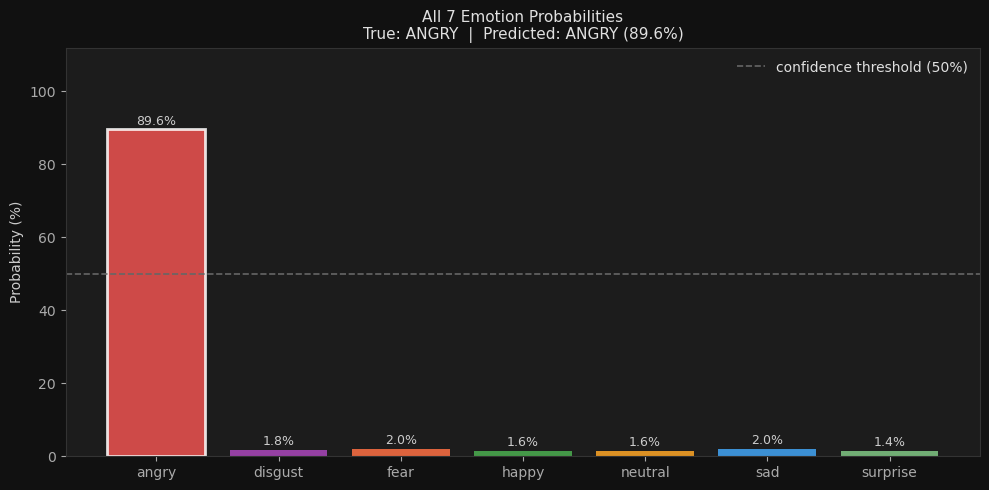


  Ground truth : DISGUST
  Predicted    : DISGUST  (89.3%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  disgust   :  89.26%  ██████████████████████████ ← top
  sad       :   2.05%  
  angry     :   1.82%  
  neutral   :   1.78%  
  happy     :   1.75%  
  fear      :   1.72%  
  surprise  :   1.63%  
  ----------------------------------------
  Sum of probs : 1.0001  (should be 1.0000)


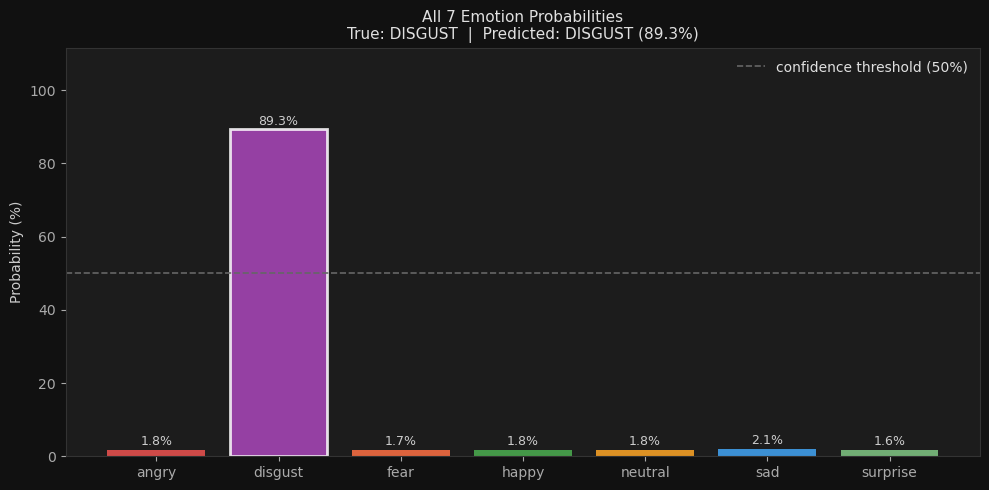


  Ground truth : FEAR
  Predicted    : FEAR  (75.1%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  fear      :  75.06%  ██████████████████████ ← top
  disgust   :   7.63%  ██
  happy     :   4.79%  █
  neutral   :   3.39%  █
  angry     :   3.27%  
  surprise  :   3.13%  
  sad       :   2.74%  
  ----------------------------------------
  Sum of probs : 1.0001  (should be 1.0000)


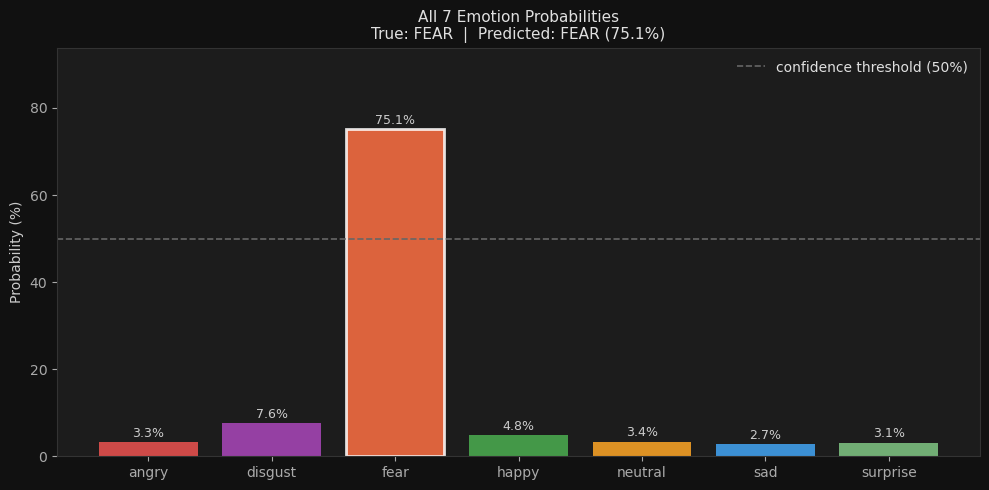


  Ground truth : HAPPY
  Predicted    : HAPPY  (88.3%)
  Polarity     : positive

  All 7 Emotion Probabilities:
  ----------------------------------------
  happy     :  88.28%  ██████████████████████████ ← top
  fear      :   2.28%  
  disgust   :   2.04%  
  angry     :   1.98%  
  surprise  :   1.88%  
  neutral   :   1.84%  
  sad       :   1.71%  
  ----------------------------------------
  Sum of probs : 1.0001  (should be 1.0000)


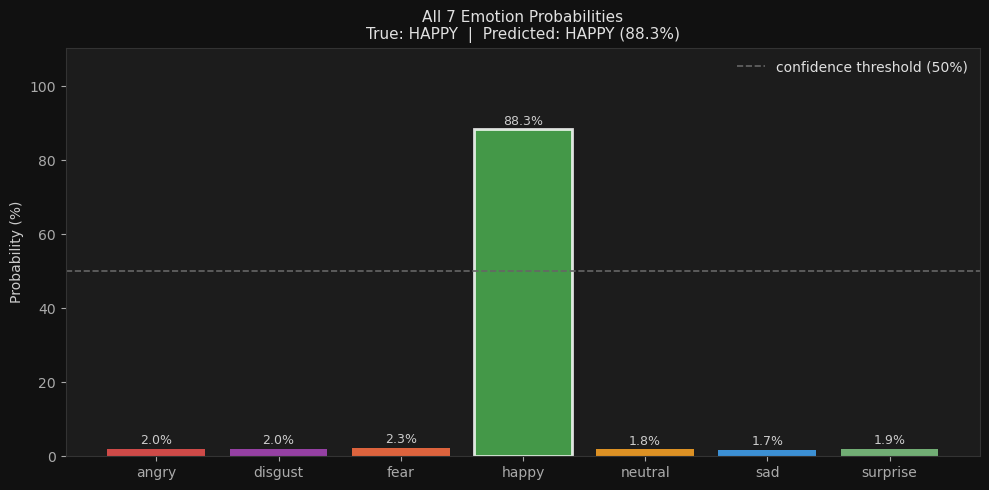


  Ground truth : NEUTRAL
  Predicted    : NEUTRAL  (69.3%)
  Polarity     : neutral

  All 7 Emotion Probabilities:
  ----------------------------------------
  neutral   :  69.31%  ████████████████████ ← top
  surprise  :  22.56%  ██████
  angry     :   2.29%  
  disgust   :   1.97%  
  sad       :   1.69%  
  fear      :   1.25%  
  happy     :   0.92%  
  ----------------------------------------
  Sum of probs : 0.9999  (should be 1.0000)


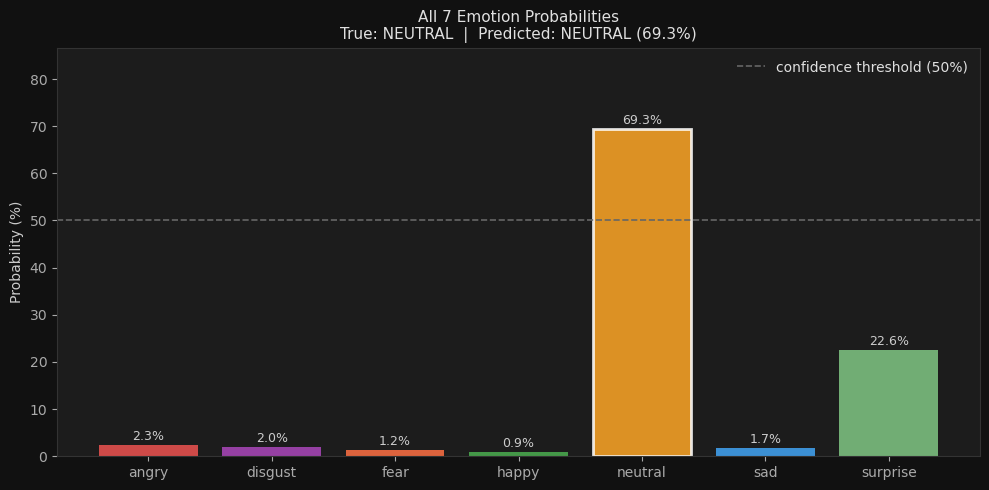


  Ground truth : SAD
  Predicted    : SAD  (83.6%)
  Polarity     : negative

  All 7 Emotion Probabilities:
  ----------------------------------------
  sad       :  83.57%  █████████████████████████ ← top
  fear      :   5.61%  █
  angry     :   3.92%  █
  disgust   :   3.05%  
  neutral   :   1.67%  
  surprise  :   1.27%  
  happy     :   0.90%  
  ----------------------------------------
  Sum of probs : 0.9999  (should be 1.0000)


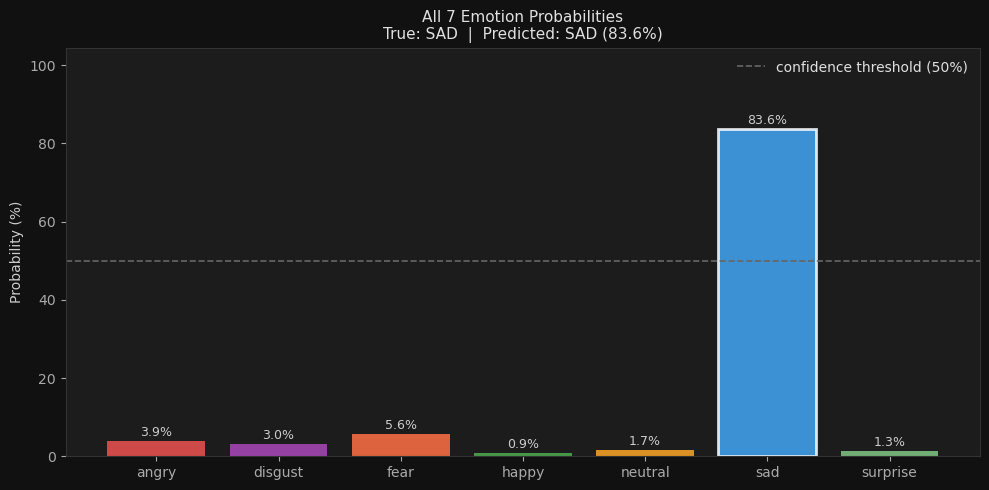


  Ground truth : SURPRISE
  Predicted    : NEUTRAL  (69.3%)
  Polarity     : neutral

  All 7 Emotion Probabilities:
  ----------------------------------------
  neutral   :  69.31%  ████████████████████ ← top
  surprise  :  22.56%  ██████
  angry     :   2.29%  
  disgust   :   1.97%  
  sad       :   1.69%  
  fear      :   1.25%  
  happy     :   0.92%  
  ----------------------------------------
  Sum of probs : 0.9999  (should be 1.0000)


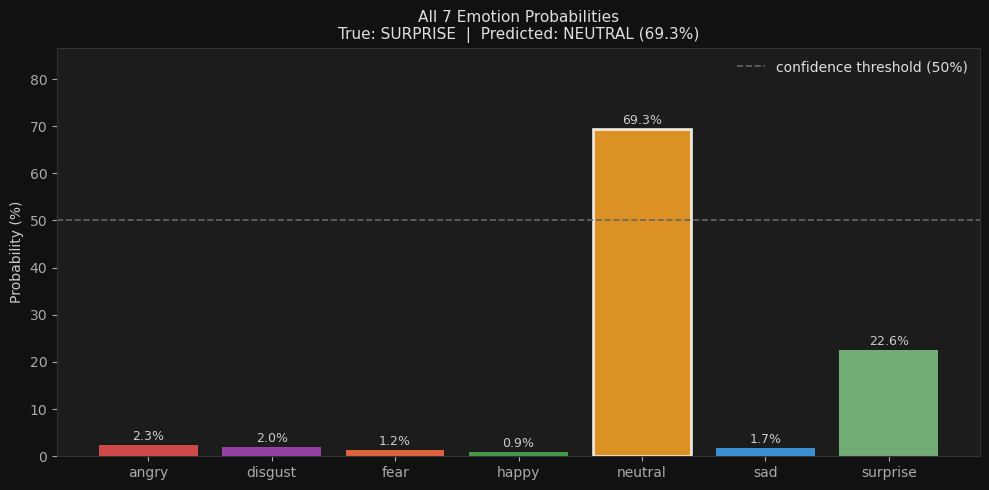

In [43]:
print('Running video demo on one sample per emotion class:\n')
for target_emo in EMOTION_CLASSES:
    idx = df_vid[df_vid['label'] == target_emo].index[0]
    rec = all_records[idx]
    demo_predict_video_from_frames(rec['frames'], label=target_emo)
    print()

## 14 – `visualise_fusion()` — 3-Panel Fusion Chart

Displays:
- **Panel 1**: A sample frame grid (4 uniformly-sampled frames) from the video clip
- **Panel 2**: Video 7-class emotion probability bar chart
- **Panel 3**: Text 3-class sentiment bar chart with mismatch severity badge


In [44]:
def visualise_fusion(frames_rgb: list, text: str,
                     result: dict = None,
                     title_label: str = ''):
    """3-panel fusion chart: frame grid | video probs | text probs + mismatch badge."""
    if result is None:
        result = run_fusion_from_frames(frames_rgb, text)
    v, t, f = result['video'], result['text'], result['fusion']

    pol_col  = {'positive':'#4CAF50','neutral':'#FFA726','negative':'#EF5350'}
    text_cols= {'negative':'#EF5350','neutral':'#FFA726','positive':'#4CAF50'}

    fig = plt.figure(figsize=(17, 5))
    gs  = fig.add_gridspec(1, 3, wspace=0.38)

    # Panel 1: 4-frame sample grid ────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0])
    n   = len(frames_rgb)
    show_idx  = np.linspace(0, n-1, 4, dtype=int)
    thumbs    = [frames_rgb[i] for i in show_idx]
    import cv2
    row1 = np.hstack([cv2.resize(thumbs[0], (112,112)), cv2.resize(thumbs[1], (112,112))])
    row2 = np.hstack([cv2.resize(thumbs[2], (112,112)), cv2.resize(thumbs[3], (112,112))])
    grid = np.vstack([row1, row2])
    ax1.imshow(grid)
    ax1.axis('off')
    ttl  = (f'Ground truth: {title_label.upper()}\n' if title_label else '')
    ttl += (f"{f['emoji']} Predicted: {v['emotion'].upper()} ({v['confidence']:.0%})\n"
            f"polarity: {v['polarity']}")
    ax1.set_title(ttl, fontsize=10, color=pol_col[v['polarity']], fontweight='bold')

    # Panel 2: video 7-class bars ─────────────────────────────────────────────
    ax2      = fig.add_subplot(gs[1])
    emotions = list(v['probs'].keys())
    probs_v  = [v['probs'][e] for e in emotions]
    colours_v= [EMOTION_COLOURS.get(e,'#aaaaaa') for e in emotions]
    bars2    = ax2.barh(emotions, probs_v, color=colours_v, alpha=0.85, edgecolor='none')
    bars2[emotions.index(v['emotion'])].set_edgecolor('white')
    bars2[emotions.index(v['emotion'])].set_linewidth(1.5)
    ax2.set_xlim(0,1); ax2.set_xlabel('Confidence')
    ax2.set_title('Video Emotion Probabilities', fontsize=10, color='#cccccc')
    ax2.axvline(CONF_THRESHOLD, color='#666', linestyle='--', linewidth=1.2,
                label=f'threshold ({CONF_THRESHOLD:.0%})')
    ax2.legend(framealpha=0, fontsize=8)
    for bar in bars2:
        w = bar.get_width()
        ax2.text(w+0.02, bar.get_y()+bar.get_height()/2,
                 f'{w:.0%}', va='center', fontsize=8, color='#aaaaaa')

    # Panel 3: text 3-class bars ──────────────────────────────────────────────
    ax3         = fig.add_subplot(gs[2])
    text_labels = ['negative','neutral','positive']
    probs_t     = [t['probs'][l] for l in text_labels]
    colours_t   = [text_cols[l] for l in text_labels]
    bars3       = ax3.barh(text_labels, probs_t, color=colours_t, alpha=0.85, edgecolor='none')
    bars3[text_labels.index(t['label'])].set_edgecolor('white')
    bars3[text_labels.index(t['label'])].set_linewidth(1.5)
    ax3.set_xlim(0,1); ax3.set_xlabel('Confidence')
    ax3.set_title(f"Text Sentiment [{f['severity']}]",
                  fontsize=10, color=f['badge_colour'], fontweight='bold')
    ax3.axvline(CONF_THRESHOLD, color='#666', linestyle='--', linewidth=1.2)
    for bar in bars3:
        w = bar.get_width()
        ax3.text(w+0.02, bar.get_y()+bar.get_height()/2,
                 f'{w:.0%}', va='center', fontsize=8, color='#aaaaaa')

    fig.text(0.5,-0.04, f'Text: "{text[:90]}"',
             ha='center', fontsize=9, color='#999', style='italic')
    fig.text(0.5,-0.10, f"Explanation: {f['explanation']}",
             ha='center', fontsize=9, color=f['badge_colour'])
    plt.suptitle('MoodSyncAI — Video + Text Fusion', fontsize=13,
                 fontweight='bold', color='#e0e0e0', y=1.04)
    plt.tight_layout()
    plt.savefig('video_text_fusion_result.png', dpi=150,
                bbox_inches='tight', facecolor='#111111')
    plt.show()
    return result


print('visualise_fusion() defined.')

visualise_fusion() defined.


## 15 – Assignment Scenario: Sad Expression + Positive Text → HARD_MISMATCH

> *"A user displays a sad facial expression in a video while saying: 'No, I think the project is going really well.'"*


Video clip (ground truth: SAD)


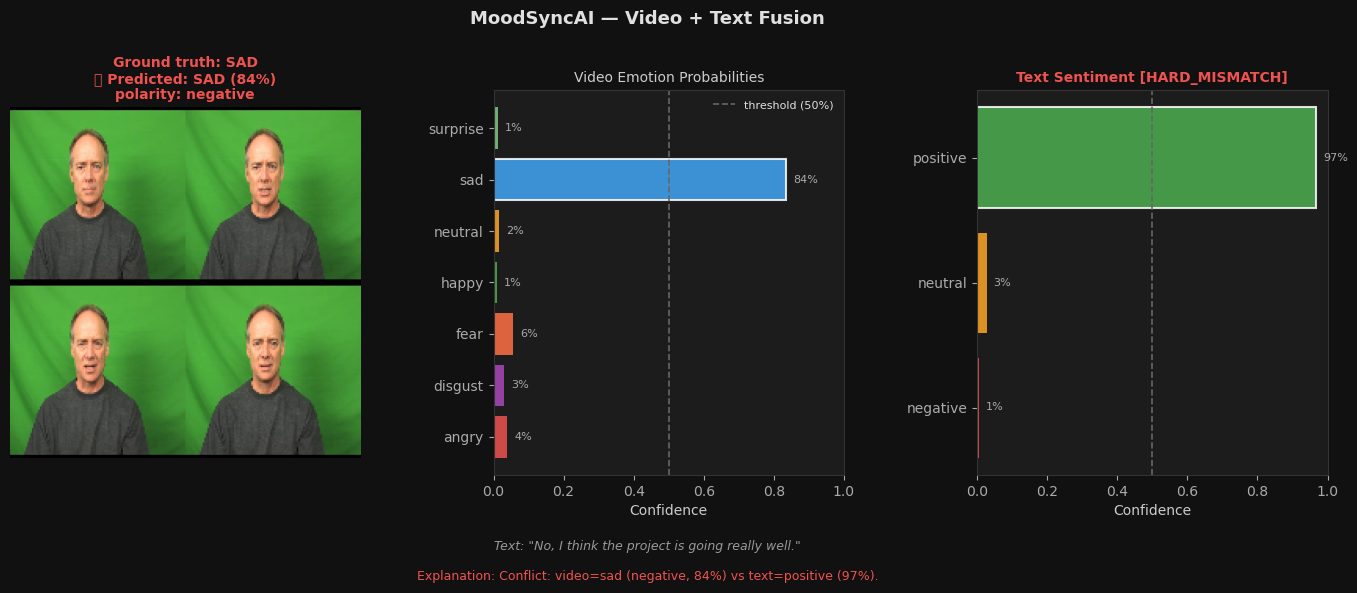


 🚨 Fusion Result : HARD_MISMATCH
 Video  : sad        conf=84% → negative
 Text   : positive   conf=97%
 Status : Conflict: video=sad (negative, 84%) vs text=positive (97%).
 Latency: 4851.9 ms

  Video 7-class probabilities:
  sad        83.6%  ████████████████ ← top
  fear       5.6%  █
  angry      3.9%  
  disgust    3.0%  
  neutral    1.7%  
  surprise   1.3%  
  happy      0.9%  

  Text probabilities:
  positive   96.7%  ███████████████████ ← top
  neutral    2.7%  
  negative   0.6%  


In [45]:
# grab a SAD sample
sad_idx    = df_vid[df_vid['label'] == 'sad'].index[0]
sad_record = all_records[sad_idx]

positive_text = "No, I think the project is going really well."

print('Video clip (ground truth: SAD)')
result = visualise_fusion(
    sad_record['frames'], positive_text,
    title_label='sad'
)
print()
print_fusion_result(result)

## 16 – Full Fusion Demo: All 7 Emotions × Match / Mismatch Text

For each emotion class we run **two** fusions:
1. A **congruent** text (same polarity → expected MATCH)
2. An **incongruent** text (opposite polarity → expected HARD_MISMATCH)


In [48]:
SCENARIO_TEXTS = {
    'happy'   : ('Everything is wonderful today!'     , 'This is absolutely terrible.'),
    'sad'     : ('I feel so low and hopeless.'         , 'This is the best day of my life!'),
    'angry'   : ('I am furious about this situation.'  , 'How delightful, I love this!'),
    'fear'    : ('I am terrified, something is wrong.' , 'I feel completely safe and calm.'),
    'disgust' : ('That is revolting and unacceptable.' , 'What a lovely and pleasant thing!'),
    'neutral' : ('The meeting is scheduled for Monday.', 'I am absolutely devastated today.'),
    'surprise': ('Oh wow, I cannot believe this!'      , 'Nothing ever happens around here.'),
}

print('Running full fusion demo...\n')
for emo in EMOTION_CLASSES:
    idx = df_vid[df_vid['label'] == emo].index[0]
    rec = all_records[idx]
    congruent_text, incongruent_text = SCENARIO_TEXTS[emo]

    print(f"\n{'='*60}")
    print(f'  EMOTION: {emo.upper()}')
    print(f"\n{'='*60}")

    print(f'\n--- Congruent text: "{congruent_text}" ---')
    r1 = run_fusion_from_frames(rec['frames'], congruent_text)
    print_fusion_result(r1)

    print(f'\n--- Incongruent text: "{incongruent_text}" ---')
    r2 = run_fusion_from_frames(rec['frames'], incongruent_text)
    print_fusion_result(r2)
    print()

Running full fusion demo...


  EMOTION: ANGRY


--- Congruent text: "I am furious about this situation." ---
 ✅ Fusion Result : MATCH
 Video  : angry      conf=90% → negative
 Text   : negative   conf=93%
 Status : Both agree: video shows angry (negative) and text is negative.
 Latency: 6646.0 ms

  Video 7-class probabilities:
  angry      89.6%  █████████████████ ← top
  sad        2.0%  
  fear       2.0%  
  disgust    1.8%  
  neutral    1.6%  
  happy      1.6%  
  surprise   1.4%  

  Text probabilities:
  negative   93.3%  ██████████████████ ← top
  neutral    5.9%  █
  positive   0.8%  

--- Incongruent text: "How delightful, I love this!" ---
 🚨 Fusion Result : HARD_MISMATCH
 Video  : angry      conf=90% → negative
 Text   : positive   conf=98%
 Status : Conflict: video=angry (negative, 90%) vs text=positive (98%).
 Latency: 3557.5 ms

  Video 7-class probabilities:
  angry      89.6%  █████████████████ ← top
  sad        2.0%  
  fear       2.0%  
  disgust    1.8%  
  neut

## 17 – Mismatch Rate Analysis (200-sample Stratified Sample)

We run the full fusion pipeline on a 200-sample stratified sample (≈28–29 per class)
using a neutral probe text so the mismatch signal comes purely from the video model.


In [49]:
import random
random.seed(42)

PROBE_TEXT   = 'The meeting has been rescheduled for next Tuesday.'
N_PER_CLASS  = 28

sample_records = []
for emo in EMOTION_CLASSES:
    pool = df_vid[df_vid['label'] == emo].index.tolist()
    chosen = random.sample(pool, min(N_PER_CLASS, len(pool)))
    for idx in chosen:
        sample_records.append((all_records[idx], emo))

print(f'Evaluating {len(sample_records)} clips...')
fusion_log = []
for rec, true_emo in sample_records:
    r = run_fusion_from_frames(rec['frames'], PROBE_TEXT)
    fusion_log.append({
        'true_emotion'   : true_emo,
        'pred_emotion'   : r['video']['emotion'],
        'video_conf'     : r['video']['confidence'],
        'video_polarity' : r['video']['polarity'],
        'text_sentiment' : r['text']['label'],
        'severity'       : r['fusion']['severity'],
    })

log_df = pd.DataFrame(fusion_log)
print('\nSeverity distribution:')
print(log_df['severity'].value_counts().to_string())
print('\nMismatch rate by emotion:')
pivot = log_df.groupby(['true_emotion','severity']).size().unstack(fill_value=0)
print(pivot.to_string())

Evaluating 62 clips...

Severity distribution:
severity
HARD_MISMATCH    47
MATCH            10
SOFT_MISMATCH     5

Mismatch rate by emotion:
severity      HARD_MISMATCH  MATCH  SOFT_MISMATCH
true_emotion                                     
angry                     9      0              1
disgust                  10      0              0
fear                     10      0              0
happy                    10      0              0
neutral                   0      8              2
sad                       8      0              2
surprise                  0      2              0


## 18 – Mismatch Visualisation Charts

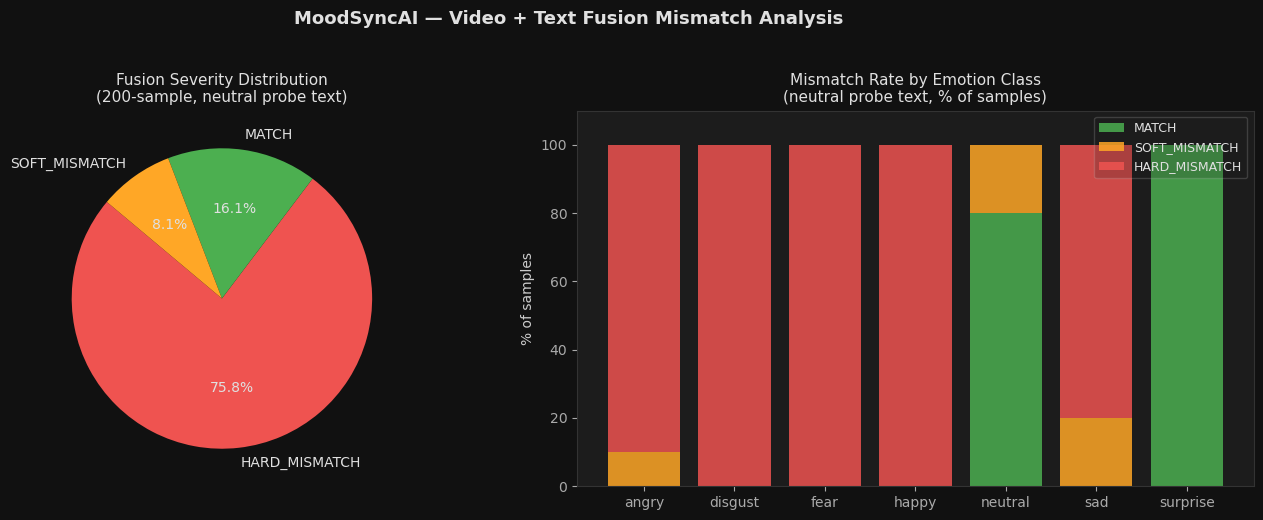

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Pie chart ────────────────────────────────────────────────────────────────
sev_counts = log_df['severity'].value_counts()
pie_cols   = [SEVERITY_COLOURS[s] for s in sev_counts.index]
axes[0].pie(sev_counts.values, labels=sev_counts.index,
            colors=pie_cols, autopct='%1.1f%%',
            startangle=140, textprops={'color':'#e0e0e0'})
axes[0].set_title('Fusion Severity Distribution\n(200-sample, neutral probe text)',
                  fontsize=11, color='#e0e0e0')

# ── Stacked bar per emotion ──────────────────────────────────────────────────
sev_order = ['MATCH','SOFT_MISMATCH','HARD_MISMATCH']
emotion_sev = (log_df.groupby(['true_emotion','severity'])
               .size().unstack(fill_value=0)
               .reindex(columns=sev_order, fill_value=0))
emotion_sev_pct = emotion_sev.div(emotion_sev.sum(axis=1), axis=0) * 100

bottom = np.zeros(len(emotion_sev_pct))
for sev in sev_order:
    if sev in emotion_sev_pct.columns:
        vals = emotion_sev_pct[sev].values
        axes[1].bar(emotion_sev_pct.index, vals, bottom=bottom,
                    color=SEVERITY_COLOURS[sev], label=sev, alpha=0.85)
        bottom += vals

axes[1].set_title('Mismatch Rate by Emotion Class\n(neutral probe text, % of samples)',
                  fontsize=11, color='#e0e0e0')
axes[1].set_ylabel('% of samples')
axes[1].set_ylim(0, 110)
axes[1].legend(loc='upper right', framealpha=0.2, fontsize=9)

plt.suptitle('MoodSyncAI — Video + Text Fusion Mismatch Analysis',
             fontsize=13, fontweight='bold', color='#e0e0e0', y=1.03)
plt.tight_layout()
plt.savefig('video_text_fusion_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()

## 19 – Confidence vs. Correctness Scatter

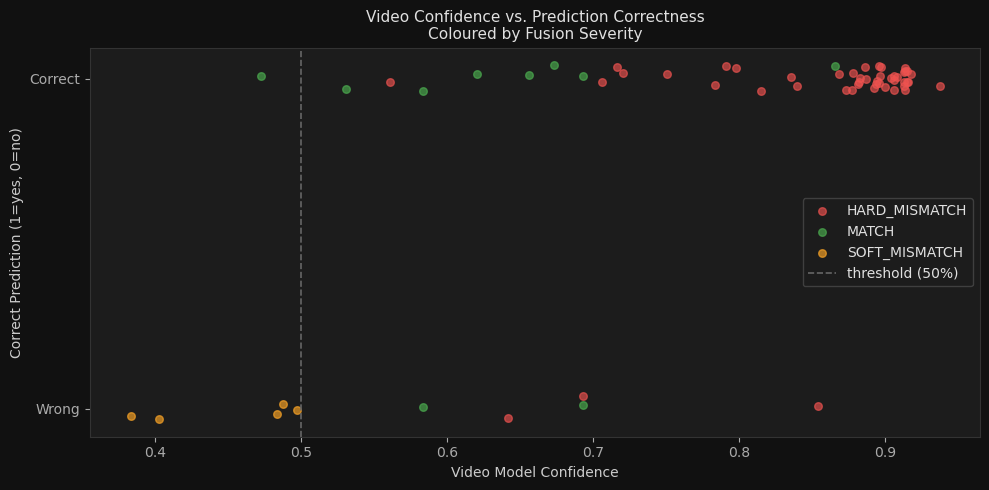

In [51]:
log_df['correct'] = (log_df['true_emotion'] == log_df['pred_emotion']).astype(int)

fig, ax = plt.subplots(figsize=(10, 5))
for sev, grp in log_df.groupby('severity'):
    ax.scatter(grp['video_conf'], grp['correct'] + np.random.uniform(-0.04, 0.04, len(grp)),
               color=SEVERITY_COLOURS[sev], alpha=0.65, label=sev, s=30)

ax.axvline(CONF_THRESHOLD, color='#666', linestyle='--', linewidth=1.2,
           label=f'threshold ({CONF_THRESHOLD:.0%})')
ax.set_xlabel('Video Model Confidence')
ax.set_ylabel('Correct Prediction (1=yes, 0=no)')
ax.set_title('Video Confidence vs. Prediction Correctness\nColoured by Fusion Severity',
             fontsize=11, color='#e0e0e0')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Wrong', 'Correct'])
ax.legend(framealpha=0.2)
plt.tight_layout()
plt.savefig('video_text_confidence_scatter.png', dpi=150,
            bbox_inches='tight', facecolor='#111111')
plt.show()

## 20 – Summary & Key Design Decisions

| Decision | Choice | Rationale |
|---|---|---|
| Video backbone | R3D-18 (Kinetics-400) | 3D conv captures spatio-temporal dynamics; pretrained features transfer well to facial emotion |
| Temporal pooling | Soft Attention | Weights the most emotionally salient frames over uniform average |
| Frame sampling | 16 uniform frames | Balances temporal coverage vs. memory; identical to NB 7 |
| Text model | RoBERTa (3-class) | Same model as NB 6 — consistent polarity space |
| Polarity bridge | `positive / neutral / negative` | Coarse but robust to class imbalance; enables clean MATCH/MISMATCH logic |
| Mismatch threshold | 0.50 | Balances precision vs. recall; tunable via `CONF_THRESHOLD` |
| Probe text in analysis | Neutral sentence | Isolates video model performance; any mismatch stems from video, not text |

### Saved Output Files
| File | Contents |
|---|---|
| `video_demo_7class.png` | Last per-class emotion bar chart |
| `video_text_fusion_result.png` | Frame grid + dual probability panels |
| `video_text_fusion_analysis.png` | Severity pie + stacked bar |
| `video_text_confidence_scatter.png` | Confidence vs. correctness scatter |


In [52]:
# Inspect checkpoint keys and shapes for debugging (focused)
ck = torch.load(VIDEO_MODEL_PATH, map_location='cpu')
sd_raw = ck.get('state_dict', ck.get('model', ck))
print('Total keys in checkpoint:', len(sd_raw))
for k, v in sd_raw.items():
    shp = tuple(v.shape) if hasattr(v, 'shape') else 'n/a'
    if any(s in k for s in ['head', 'classifier', 'temp_attn', 'pool']):
        print(f'{k:60s} {shp}')

Total keys in checkpoint: 128
temp_attn.attn.weight                                        (1, 512)
temp_attn.attn.bias                                          (1,)
head.0.weight                                                (512,)
head.0.bias                                                  (512,)
head.1.weight                                                (256, 512)
head.1.bias                                                  (256,)
head.4.weight                                                (7, 256)
head.4.bias                                                  (7,)
